In [4]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

from collections import Counter
from wordcloud import WordCloud

In [5]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("vader_lexicon")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [6]:
data = {
    "Review": [
        "The food was delicious and the service was excellent.",
        "Delivery was very late and the food was cold.",
        "The restaurant was clean and the staff was friendly.",
        "Poor packaging and tasteless food.",
        "Amazing pizza and quick delivery.",
        "Customer service was very disappointing.",
        "Reasonable price and good quality food.",
        "The order was incorrect and arrived late.",
        "Fresh food with excellent taste.",
        "The dining experience was average."
    ]
}

df = pd.DataFrame(data)

print("Restaurant Reviews Dataset")
print(df)

Restaurant Reviews Dataset
                                              Review
0  The food was delicious and the service was exc...
1      Delivery was very late and the food was cold.
2  The restaurant was clean and the staff was fri...
3                 Poor packaging and tasteless food.
4                  Amazing pizza and quick delivery.
5           Customer service was very disappointing.
6            Reasonable price and good quality food.
7          The order was incorrect and arrived late.
8                   Fresh food with excellent taste.
9                 The dining experience was average.


In [8]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Review"] = df["Review"].apply(clean_text)

print(df[["Review","Cleaned_Review"]])

                                              Review  \
0  The food was delicious and the service was exc...   
1      Delivery was very late and the food was cold.   
2  The restaurant was clean and the staff was fri...   
3                 Poor packaging and tasteless food.   
4                  Amazing pizza and quick delivery.   
5           Customer service was very disappointing.   
6            Reasonable price and good quality food.   
7          The order was incorrect and arrived late.   
8                   Fresh food with excellent taste.   
9                 The dining experience was average.   

                       Cleaned_Review  
0    food delicious service excellent  
1             delivery late food cold  
2     restaurant clean staff friendly  
3       poor packaging tasteless food  
4        amazing pizza quick delivery  
5      customer service disappointing  
6  reasonable price good quality food  
7        order incorrect arrived late  
8          fresh food e

In [9]:
sia = SentimentIntensityAnalyzer()

def sentiment(review):

    score = sia.polarity_scores(review)["compound"]

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Review"].apply(sentiment)

print(df[["Review","Sentiment"]])

                                              Review Sentiment
0  The food was delicious and the service was exc...  Positive
1      Delivery was very late and the food was cold.   Neutral
2  The restaurant was clean and the staff was fri...  Positive
3                 Poor packaging and tasteless food.  Negative
4                  Amazing pizza and quick delivery.  Positive
5           Customer service was very disappointing.  Negative
6            Reasonable price and good quality food.  Positive
7          The order was incorrect and arrived late.   Neutral
8                   Fresh food with excellent taste.  Positive
9                 The dining experience was average.   Neutral


In [10]:
all_words = " ".join(df["Cleaned_Review"])

word_list = all_words.split()

word_freq = Counter(word_list)

print("Top 10 Common Words")

print(word_freq.most_common(10))

Top 10 Common Words
[('food', 5), ('service', 2), ('excellent', 2), ('delivery', 2), ('late', 2), ('delicious', 1), ('cold', 1), ('restaurant', 1), ('clean', 1), ('staff', 1)]


In [11]:
negative_reviews = df[df["Sentiment"]=="Negative"]

negative_words = " ".join(negative_reviews["Cleaned_Review"])

complaints = Counter(negative_words.split())

print("Common Service Issues")

print(complaints.most_common(10))

Common Service Issues
[('poor', 1), ('packaging', 1), ('tasteless', 1), ('food', 1), ('customer', 1), ('service', 1), ('disappointing', 1)]


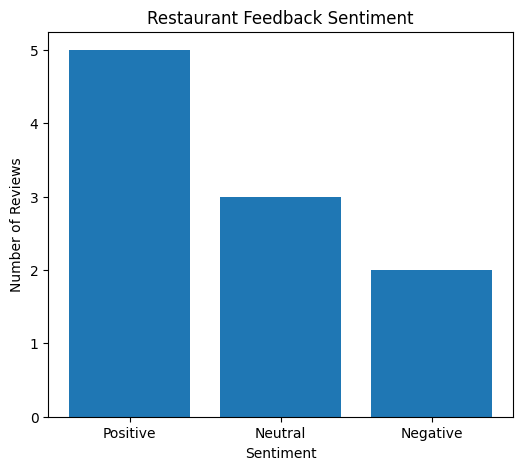

In [12]:
sentiment_count = df["Sentiment"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(sentiment_count.index, sentiment_count.values)

plt.title("Restaurant Feedback Sentiment")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

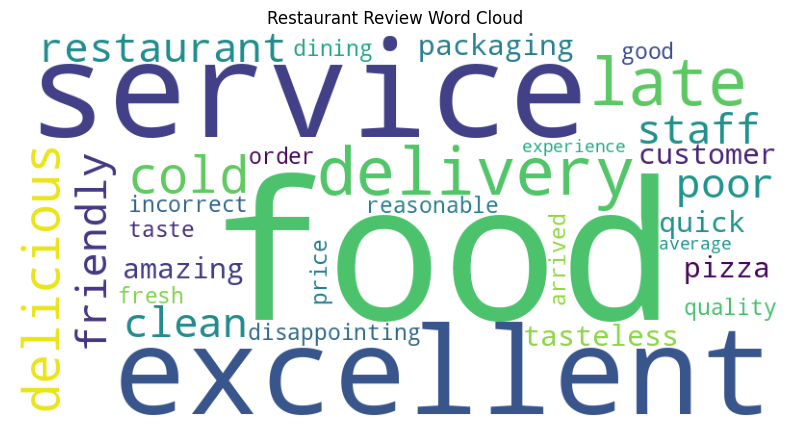

In [13]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Restaurant Review Word Cloud")

plt.show()

In [14]:
positive = len(df[df["Sentiment"]=="Positive"])
negative = len(df[df["Sentiment"]=="Negative"])
neutral = len(df[df["Sentiment"]=="Neutral"])

print("Restaurant Feedback Analysis Report")
print("----------------------------------")

print("Positive Reviews :", positive)
print("Negative Reviews :", negative)
print("Neutral Reviews :", neutral)

print("\nCommon Positive Areas")
print("- Delicious Food")
print("- Fast Delivery")
print("- Friendly Staff")
print("- Good Food Quality")

print("\nCommon Service Issues")
print("- Late Delivery")
print("- Cold Food")
print("- Poor Packaging")
print("- Poor Customer Service")

print("\nRecommendations")
print("- Improve delivery speed")
print("- Improve food packaging")
print("- Train customer support staff")
print("- Maintain food quality")

Restaurant Feedback Analysis Report
----------------------------------
Positive Reviews : 5
Negative Reviews : 2
Neutral Reviews : 3

Common Positive Areas
- Delicious Food
- Fast Delivery
- Friendly Staff
- Good Food Quality

Common Service Issues
- Late Delivery
- Cold Food
- Poor Packaging
- Poor Customer Service

Recommendations
- Improve delivery speed
- Improve food packaging
- Train customer support staff
- Maintain food quality
